Connect drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data

In [2]:
df = pd.read_csv('tweet_lyrics_vad.csv')

df.head()

,Unnamed: 0,title,artist,disorder,sentiment_direction,sentiment_score,lyric,emotion_anger_score,emotion_disgust_score,emotion_fear_score,...,mean_dominance_VAD,mean_valence_VAD,tweet_model_text,lyric_model_text,tweet_valence,tweet_arousal,tweet_dominance,lyric_valence,lyric_arousal,lyric_dominance
0,0,Burnin Bridges / Long Day (feat. IDK),Quadeca,depression,POSITIVE,0.9971,Highest To Lowest: Quadeca LyricsQuadeca's Son...,0.0294,0.0014,0.0132,...,0.075335,0.055654,"18. He/They. Bisexual. Socialist. Filmmaker, m...",Highest To Lowest: Quadeca LyricsQuadeca's Son...,2.998211,2.962549,3.045191,3.146908,3.134274,3.088945
1,1,She's A Lady,Tom Jones,control,POSITIVE,0.9988,She’s a Lady Lyrics[Verse 1]\nWell she's all y...,0.0271,0.0203,0.0071,...,0.140663,0.105500,One song everyday (hopefully) of 2020.,She’s a Lady Lyrics[Verse 1]\nWell she's all y...,3.256605,2.998280,3.037257,3.211000,3.499823,3.281325
2,2,Lilies of the Valley,David Byrne,control,POSITIVE,0.9532,Lilies of the Valley Lyrics[Verse 1]\nMomma sh...,0.0252,0.0054,0.0556,...,0.093785,-0.189674,One song everyday (hopefully) of 2020.,Lilies of the Valley Lyrics[Verse 1]\nMomma sh...,3.256605,2.998280,3.037257,2.620652,3.451024,3.187569
3,3,School's Out,Alice Cooper,control,NEGATIVE,0.9995,"School’s Out Lyrics[Verse 1]\nWell, we got no ...",0.1258,0.1330,0.0149,...,0.061629,-0.165449,One song everyday (hopefully) of 2020.,"School’s Out Lyrics[Verse 1]\nWell, we got no ...",3.256605,2.998280,3.037257,2.669102,3.398807,3.123258
4,4,Call My Friends,Shawn Mendes,depression,POSITIVE,0.9978,"Call My Friends Lyrics[Verse 1]\nRight now, I'...",0.0016,0.0006,0.0015,...,0.082034,0.017132,ariana & shawn + tom | he/him | 19,"Call My Friends Lyrics[Verse 1]\nRight now, I'...",3.053620,2.922463,3.139341,3.034263,3.343280,3.164068


Checks

In [3]:
# Normalize tweet VAD values to [-1, 1] from original model outputs
vad_columns = [
    "tweet_valence",
    "tweet_arousal",
    "tweet_dominance",
    "lyric_valence",
    "lyric_arousal",
    "lyric_dominance"
]

raw_vad_columns = [f"{c}_raw" for c in vad_columns]

# Keep original model outputs once so rerunning this cell is safe.
for col, raw_col in zip(vad_columns, raw_vad_columns):
    if raw_col not in df.columns:
        df[raw_col] = df[col]

source = df[raw_vad_columns]
src_min = source.min().min()
src_max = source.max().max()

# Recovery: if backup range is impossible, restore raw values from disk.
if src_max < -1.0 or src_min > 5.0:
    raw_df = pd.read_csv('tweet_lyrics_vad.csv', usecols=vad_columns)
    for col, raw_col in zip(vad_columns, raw_vad_columns):
        df[raw_col] = raw_df[col].to_numpy()
    source = df[raw_vad_columns]
    src_min = source.min().min()
    src_max = source.max().max()

if 1.0 <= src_min and src_max <= 5.0:
    normalized = (source - 3.0) / 2.0
elif 0.0 <= src_min and src_max <= 1.0:
    normalized = source * 2.0 - 1.0
elif -1.0 <= src_min and src_max <= 1.0:
    normalized = source.copy()
else:
    raise ValueError(
        f"Unexpected tweet VAD range: [{src_min:.4f}, {src_max:.4f}]. "
        "Expected [1,5], [0,1], or [-1,1]."
    )

df[vad_columns] = normalized.to_numpy()
df[vad_columns] = df[vad_columns].clip(-1, 1)

In [4]:
df[vad_columns] = df[vad_columns].clip(-1, 1)

In [5]:
pd.concat(
    [
        df[raw_vad_columns].describe().loc[['min', 'max', 'mean']],
        df[vad_columns].describe().loc[['min', 'max', 'mean']]
    ],
    axis=1
 )

,tweet_valence_raw,tweet_arousal_raw,tweet_dominance_raw,lyric_valence_raw,lyric_arousal_raw,lyric_dominance_raw,tweet_valence,tweet_arousal,tweet_dominance,lyric_valence,lyric_arousal,lyric_dominance
min,1.716019,2.443162,2.496148,1.656026,2.545173,2.563488,-0.641991,-0.278419,-0.251926,-0.671987,-0.227413,-0.218256
max,4.345876,4.225486,3.776844,4.320788,4.368503,3.680152,0.672938,0.612743,0.388422,0.660394,0.684251,0.340076
mean,3.051850,3.079540,3.127424,2.920152,3.461557,3.151433,0.025925,0.039770,0.063712,-0.039924,0.230778,0.075716


In [6]:
df['valence_diff'] = abs (
    df['tweet_valence'] - df['lyric_valence']
)

df['arousal_diff'] = abs (
    df['tweet_arousal'] - df['lyric_arousal']
)

df['dominance_diff'] = abs (
    df['tweet_dominance'] - df['lyric_dominance']
)

In [7]:
df['vad_distance'] = np.linalg.norm(
    df[['tweet_valence', 'tweet_arousal', 'tweet_dominance']].to_numpy() -
    df[['lyric_valence', 'lyric_arousal', 'lyric_dominance']].to_numpy(),
    axis=1
)

In [8]:
df.head()

,Unnamed: 0,title,artist,disorder,sentiment_direction,sentiment_score,lyric,emotion_anger_score,emotion_disgust_score,emotion_fear_score,...,tweet_valence_raw,tweet_arousal_raw,tweet_dominance_raw,lyric_valence_raw,lyric_arousal_raw,lyric_dominance_raw,valence_diff,arousal_diff,dominance_diff,vad_distance
0,0,Burnin Bridges / Long Day (feat. IDK),Quadeca,depression,POSITIVE,0.9971,Highest To Lowest: Quadeca LyricsQuadeca's Son...,0.0294,0.0014,0.0132,...,2.998211,2.962549,3.045191,3.146908,3.134274,3.088945,0.074349,0.085863,0.021877,0.115666
1,1,She's A Lady,Tom Jones,control,POSITIVE,0.9988,She’s a Lady Lyrics[Verse 1]\nWell she's all y...,0.0271,0.0203,0.0071,...,3.256605,2.998280,3.037257,3.211000,3.499823,3.281325,0.022802,0.250772,0.122034,0.279819
2,2,Lilies of the Valley,David Byrne,control,POSITIVE,0.9532,Lilies of the Valley Lyrics[Verse 1]\nMomma sh...,0.0252,0.0054,0.0556,...,3.256605,2.998280,3.037257,2.620652,3.451024,3.187569,0.317976,0.226372,0.075156,0.397494
3,3,School's Out,Alice Cooper,control,NEGATIVE,0.9995,"School’s Out Lyrics[Verse 1]\nWell, we got no ...",0.1258,0.1330,0.0149,...,3.256605,2.998280,3.037257,2.669102,3.398807,3.123258,0.293752,0.200263,0.043000,0.358112
4,4,Call My Friends,Shawn Mendes,depression,POSITIVE,0.9978,"Call My Friends Lyrics[Verse 1]\nRight now, I'...",0.0016,0.0006,0.0015,...,3.053620,2.922463,3.139341,3.034263,3.343280,3.164068,0.009678,0.210409,0.012364,0.210994


In [9]:
df.describe()

,Unnamed: 0,sentiment_score,emotion_anger_score,emotion_disgust_score,emotion_fear_score,emotion_joy_score,emotion_neutral_score,emotion_sadness_score,emotion_surprise_score,mean_arousal_VAD,...,tweet_valence_raw,tweet_arousal_raw,tweet_dominance_raw,lyric_valence_raw,lyric_arousal_raw,lyric_dominance_raw,valence_diff,arousal_diff,dominance_diff,vad_distance
count,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000,53025.000000,...,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000,55757.000000
mean,39262.152680,0.989368,0.196324,0.029633,0.163287,0.121884,0.125805,0.254508,0.108559,0.207708,...,3.051850,3.079540,3.127424,2.920152,3.461557,3.151433,0.151570,0.211766,0.066614,0.298856
std,22662.443934,0.035435,0.254349,0.063543,0.274235,0.203507,0.149748,0.300735,0.172708,0.078285,...,0.261847,0.254836,0.124852,0.266239,0.154786,0.115182,0.122751,0.117775,0.052105,0.120806
min,0.000000,0.500300,0.000500,0.000100,0.000200,0.000400,0.000200,0.000700,0.000300,-0.227413,...,1.716019,2.443162,2.496148,1.656026,2.545173,2.563488,0.000001,0.000006,0.000001,0.004013
25%,19958.000000,0.992700,0.016500,0.002000,0.009800,0.011300,0.020900,0.037200,0.014300,0.159608,...,2.960123,2.879894,3.053650,2.737298,3.361953,3.082000,0.055996,0.120183,0.026531,0.211469
50%,38245.000000,0.996700,0.070200,0.008400,0.034500,0.034000,0.067800,0.104600,0.041000,0.210123,...,3.059682,3.042461,3.113226,2.926302,3.463472,3.160917,0.123238,0.209082,0.055756,0.291473
75%,58785.000000,0.998200,0.291400,0.030100,0.142600,0.120800,0.176800,0.382200,0.118300,0.256957,...,3.162013,3.209534,3.188046,3.096412,3.558266,3.227302,0.216033,0.296743,0.094098,0.376206
max,78412.000000,0.999500,0.994400,0.972000,0.995400,0.994700,0.944900,0.993500,0.985800,0.633418,...,4.345876,4.225486,3.776844,4.320788,4.368503,3.680152,0.971615,0.710099,0.427616,1.064456


Plots

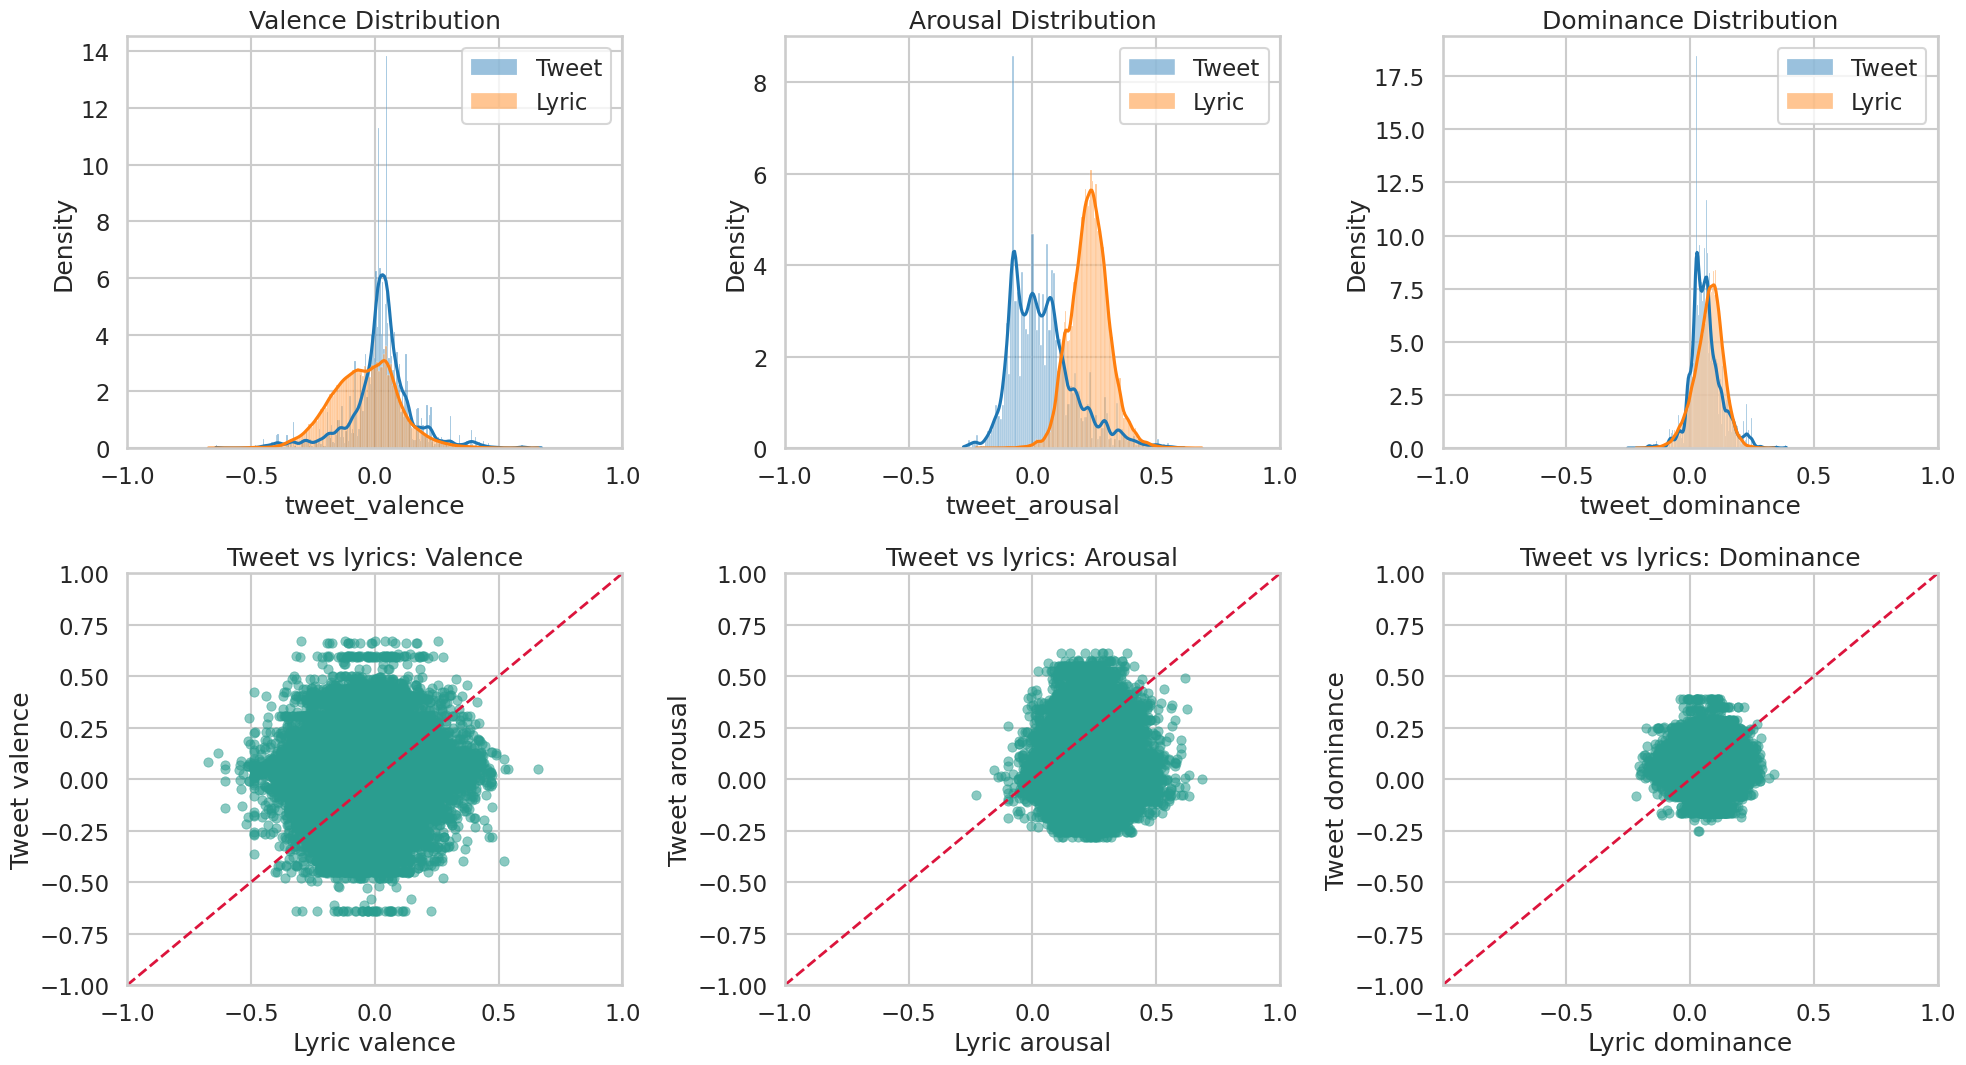

In [12]:
sns.set_theme(style="whitegrid", context="talk")

pairs = [
    ("tweet_valence", "lyric_valence", "Valence"),
    ("tweet_arousal", "lyric_arousal", "Arousal"),
    ("tweet_dominance", "lyric_dominance", "Dominance")
]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

for i, (tweet_col, lyric_col, label) in enumerate(pairs):
    ax = axes[0, i]
    sns.histplot(df[tweet_col], color="#1f77b4", label="Tweet", kde=True, stat="density", alpha=0.45, ax=ax)
    sns.histplot(df[lyric_col], color="#ff7f0e", label="Lyric", kde=True, stat="density", alpha=0.45, ax=ax)
    ax.set_title(f"{label} Distribution")
    ax.set_xlim(-1, 1)
    ax.legend()

    ax = axes[1, i]
    sns.scatterplot(
        data=df,
        x=lyric_col,
        y=tweet_col,
        alpha=0.55,
        s=45,
        color='#2a9d8f',
        edgecolor=None,
        ax=ax
    )
    ax.plot([-1, 1], [-1, 1], linestyle="--", color='crimson', linewidth=2)
    ax.set_title(f"Tweet vs lyrics: {label}")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel(f"Lyric {label.lower()}")
    ax.set_ylabel(f"Tweet {label.lower()}")

plt.tight_layout()
plt.show()

In [10]:
sns.set_theme(style="whitegrid", context="talk")

group_col = "disorder"
group_order = ["control", "depression"]
palette = {"control": "#4C72B0", "depression": "#E45756"}

vad_dims = ["valence", "arousal", "dominance"]
lyric_cols = [f"lyric_{dim}" for dim in vad_dims]
tweet_cols = [f"tweet_{dim}" for dim in vad_dims]
diff_cols = ["valence_diff", "arousal_diff", "dominance_diff", "vad_distance"]

plot_df = df[df[group_col].isin(group_order)].copy()
plot_df[group_col] = pd.Categorical(plot_df[group_col], categories=group_order, ordered=True)

Group differences -> lyrics

/tmp/ipykernel_614/3394407438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_614/3394407438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_614/3394407438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


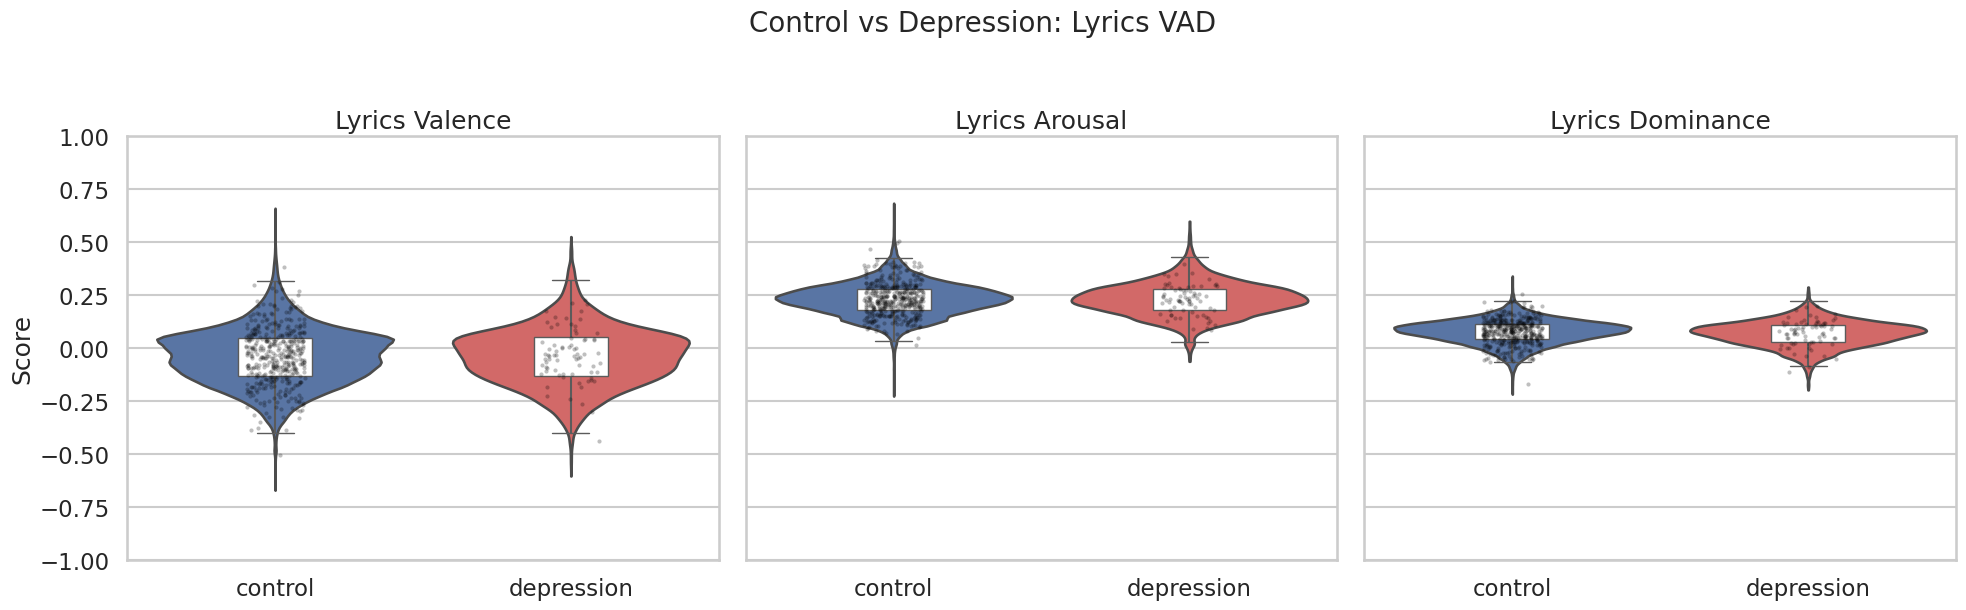

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, dim in zip(axes, vad_dims):
    col = f"lyric_{dim}"
    sns.violinplot(
        data=plot_df,
        x=group_col,
        y=col,
        order=group_order,
        palette=palette,
        inner=None,
        cut=0,
        ax=ax
    )

    sns.boxplot(
        data=plot_df,
        x=group_col,
        y=col,
        order=group_order,
        width=0.25,
        showcaps=True,
        boxprops={"facecolor": "white", "zorder": 3},
        whiskerprops={"linewidth": 1.5},
        medianprops={"color": "black", "linewidth": 2},
        showfliers=False,
        ax=ax
    )

    sns.stripplot(
        data=plot_df.sample(min(len(plot_df), 500), random_state=42),
        x=group_col,
        y=col,
        order=group_order,
        color="black",
        alpha=0.25,
        size=3,
        ax=ax
    )

    ax.set_title(f"Lyrics {dim.capitalize()}")
    ax.set_xlabel("")
    ax.set_ylabel("Score" if dim == "valence" else "")
    ax.set_ylim(-1, 1)

fig.suptitle("Control vs Depression: Lyrics VAD", y=1.03, fontsize=20)
plt.tight_layout()
plt.show()

Group differences -> tweets

/tmp/ipykernel_614/1887519379.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_614/1887519379.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_614/1887519379.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


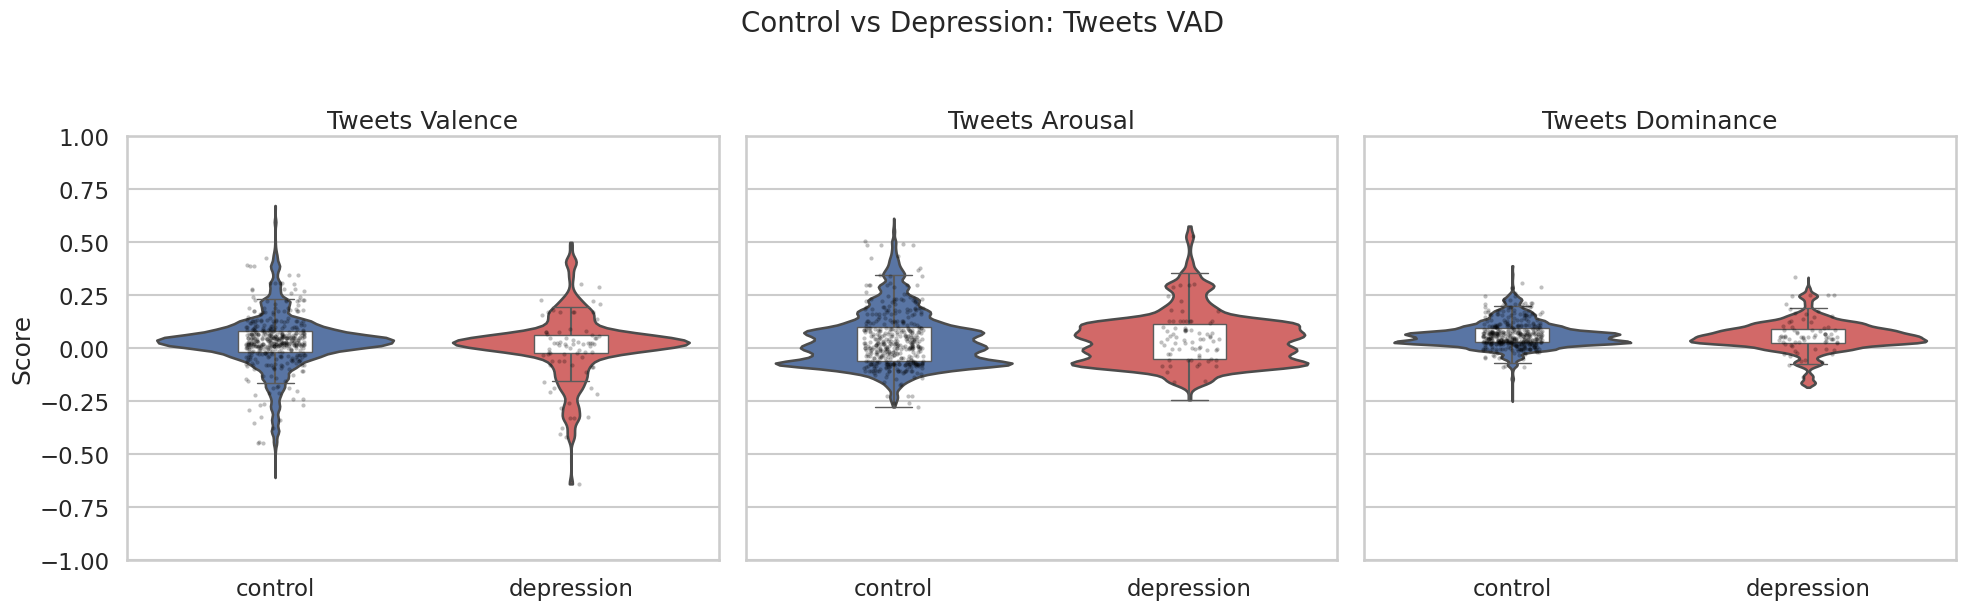

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, dim in zip(axes, vad_dims):
    col = f"tweet_{dim}"
    sns.violinplot(
        data=plot_df,
        x=group_col,
        y=col,
        order=group_order,
        palette=palette,
        inner=None,
        cut=0,
        ax=ax
    )

    sns.boxplot(
        data=plot_df,
        x=group_col,
        y=col,
        order=group_order,
        width=0.25,
        showcaps=True,
        boxprops={"facecolor": "white", "zorder": 3},
        whiskerprops={"linewidth": 1.5},
        medianprops={"color": "black", "linewidth": 2},
        showfliers=False,
        ax=ax
    )

    sns.stripplot(
        data=plot_df.sample(min(len(plot_df), 500), random_state=42),
        x=group_col,
        y=col,
        order=group_order,
        color="black",
        alpha=0.25,
        size=3,
        ax=ax
    )

    ax.set_title(f"Tweets {dim.capitalize()}")
    ax.set_xlabel("")
    ax.set_ylabel("Score" if dim == "valence" else "")
    ax.set_ylim(-1, 1)

fig.suptitle("Control vs Depression: Tweets VAD", y=1.03, fontsize=20)
plt.tight_layout()
plt.show()

Relation between Lyrics and Tweets

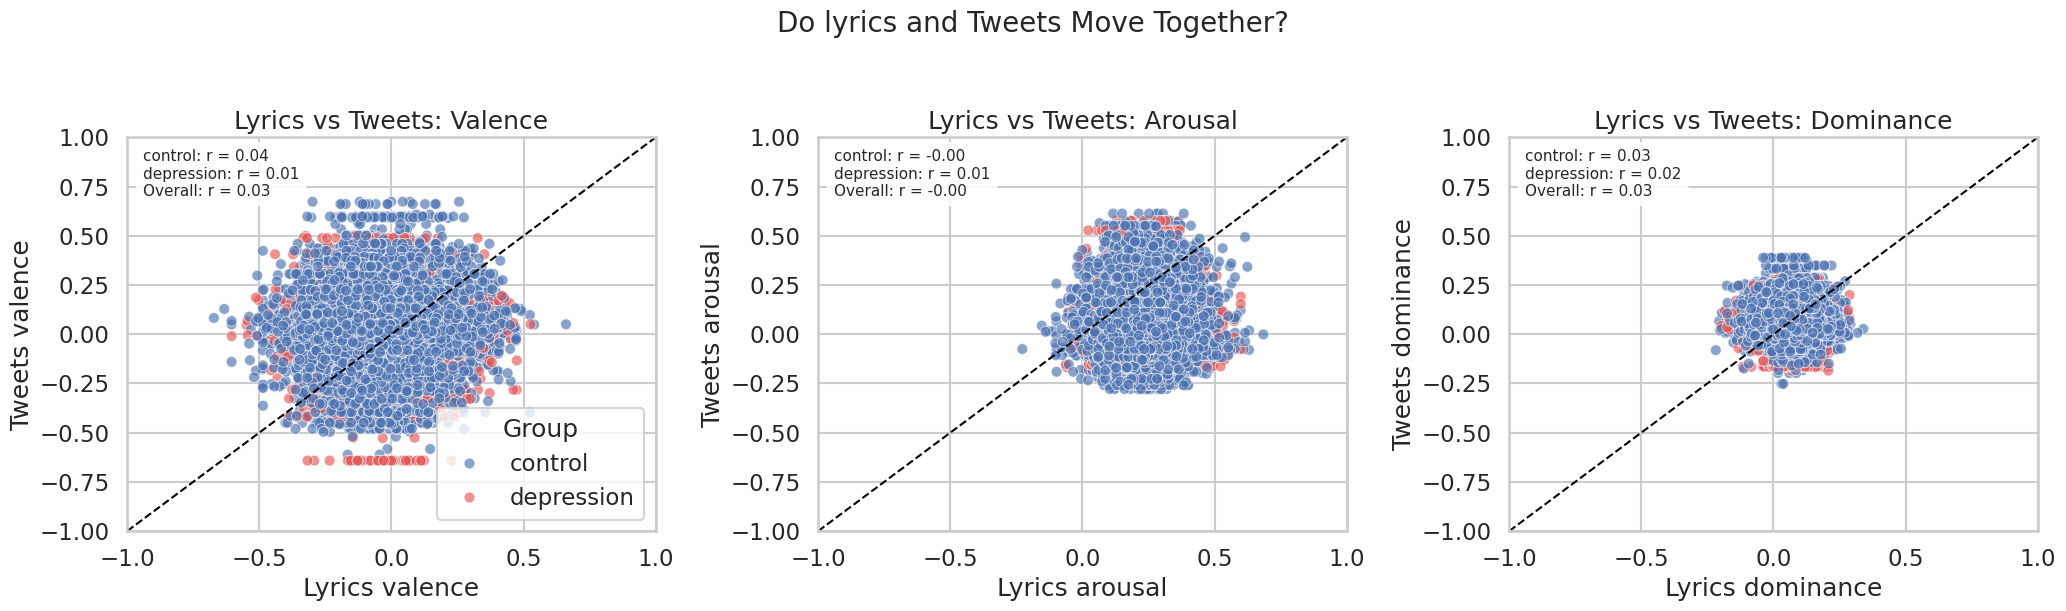

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

corr_rows = []

for ax, dim in zip(axes, vad_dims):
    x_col = f"lyric_{dim}"
    y_col = f"tweet_{dim}"

    sns.scatterplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        hue=group_col,
        hue_order=group_order,
        palette=palette,
        alpha=0.65,
        s=60,
        ax=ax
    )

    ax.plot([-1, 1], [-1, 1], linestyle="--", color="black", linewidth=1.5)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_title(f"Lyrics vs Tweets: {dim.capitalize()}")
    ax.set_xlabel(f"Lyrics {dim}")
    ax.set_ylabel(f"Tweets {dim}")

    text_lines = []
    for group in group_order:
        sub = plot_df[plot_df[group_col] == group]
        r = sub[[x_col, y_col]].corr().iloc[0, 1]
        corr_rows.append({
            "group": group,
            "dimension": dim,
            "correlation": r
        })
        text_lines.append(f"{group}: r = {r:.2f}")

    overall_r = plot_df[[x_col, y_col]].corr().iloc[0, 1]
    text_lines.append(f"Overall: r = {overall_r:.2f}")

    ax.text(
        0.03, 0.97,
        "\n".join(text_lines),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85)
    )

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title="Group")
for ax in axes[1:]:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

fig.suptitle("Do lyrics and Tweets Move Together?", y=1.03, fontsize=20)
plt.tight_layout()
plt.show()

Cross-modal gap by group

/tmp/ipykernel_614/1528333043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_614/1528333043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_614/1528333043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_614/1528333043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


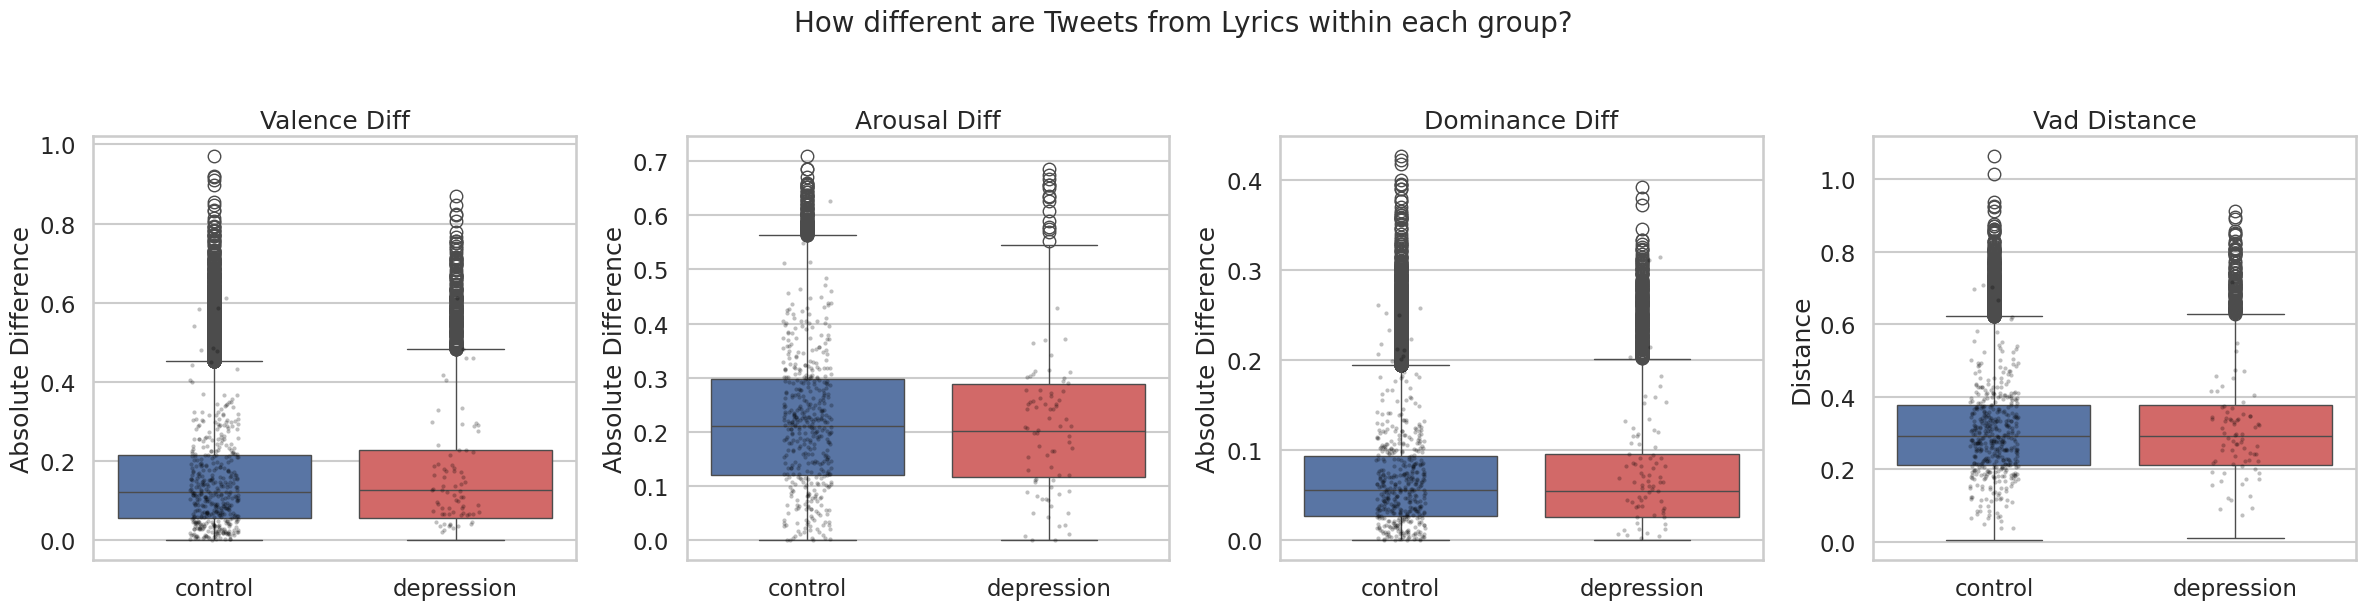

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, col in zip(axes, diff_cols):
    sns.boxplot(
        data=plot_df,
        x=group_col,
        y=col,
        order=group_order,
        palette=palette,
        ax=ax
    )

    sns.stripplot(
        data=plot_df.sample(min(len(plot_df), 500), random_state=42),
        x=group_col,
        y=col,
        order=group_order,
        color="black",
        alpha=0.25,
        size=3,
        ax=ax
    )

    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel("")
    ax.set_ylabel("Distance" if col == "vad_distance" else "Absolute Difference")

fig.suptitle("How different are Tweets from Lyrics within each group?", y=1.03, fontsize=20)
plt.tight_layout()
plt.show()

Summary Tables

In [11]:
summary_means = (
    plot_df
    .groupby(group_col)[lyric_cols + tweet_cols + diff_cols]
    .aggregate(['mean', 'std', 'median'])
    .round(3)
)

corr_table = pd.DataFrame(corr_rows).pivot(index="dimension", columns="group", values="correlation").round(3)

display(summary_means)
display(corr_table)

NameError: name 'corr_rows' is not defined

Final tests

In [12]:
from scipy.stats import spearmanr, mannwhitneyu

group_col = "disorder"
group_order = ["control", "depression"]
vad_dims = ["valence", "arousal", "dominance"]

results = []

for dim in vad_dims:
    x_col = f"lyric_{dim}"
    y_col = f"tweet_{dim}"

    # Overall correlation
    pearson_r = df[[x_col, y_col]].corr(method="pearson").iloc[0, 1]
    spearman_r, spearman_p = spearmanr(df[x_col], df[y_col], nan_policy="omit")

    # Correlation by group
    for group in group_order:
        sub = df[df[group_col] == group]
        pr = sub[[x_col, y_col]].corr(method="pearson").iloc[0, 1]
        sr, sp = spearmanr(sub[x_col], sub[y_col], nan_policy="omit")
        results.append({
            "dimension": dim,
            "group": group,
            "type": "within-group",
            "pearson_r": pr,
            "spearman_r": sr,
            "spearman_p": sp
        })

    results.append({
        "dimension": dim,
        "group": "overall",
        "type": "overall",
        "pearson_r": pearson_r,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

# Group differences in tweet-lyric gaps
gap_results = []
for col in ["valence_diff", "arousal_diff", "dominance_diff", "vad_distance"]:
    control_vals = df[df[group_col] == "control"][col]
    depression_vals = df[df[group_col] == "depression"][col]

    stat, p_value = mannwhitneyu(control_vals, depression_vals, alternative="two-sided")

    gap_results.append({
        "gap_metric": col,
        "control_mean": control_vals.mean(),
        "depression_mean": depression_vals.mean(),
        "mannwhitney_p": p_value,
    })

results_df = pd.DataFrame(results)
gap_df = pd.DataFrame(gap_results)

display(results_df.round(4))
display(gap_df.round(4))

,dimension,group,type,pearson_r,spearman_r,spearman_p
0,valence,control,within-group,0.0380,0.0521,0.0000
1,valence,depression,within-group,0.0074,0.0202,0.0800
2,valence,overall,overall,0.0332,0.0478,0.0000
3,arousal,control,within-group,-0.0026,-0.0085,0.0634
4,arousal,depression,within-group,0.0139,0.0074,0.5235
5,arousal,overall,overall,-0.0003,-0.0061,0.1519
6,dominance,control,within-group,0.0266,0.0333,0.0000
7,dominance,depression,within-group,0.0218,0.0282,0.0145
8,dominance,overall,overall,0.0286,0.0336,0.0000


,gap_metric,control_mean,depression_mean,mannwhitney_p
0,valence_diff,0.1504,0.1589,0.0000
1,arousal_diff,0.2127,0.2056,0.0000
2,dominance_diff,0.0662,0.0692,0.4972
3,vad_distance,0.2986,0.3007,0.6292


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Optional: install if needed
# pip install shap
import shap


# ============================================================
# Explainability Gate: Is SHAP Worth It?
# ============================================================
# Rule:
# - If cross-validated AUROC is near 0.50-0.58, SHAP is likely not informative.
# - If AUROC is clearly above chance, for example >= 0.60, use SHAP to explain drivers.
# ============================================================


group_col = "disorder"

label_map = {
    "control": 0,
    "depression": 1
}


base_feats = [
    "lyric_valence",
    "lyric_arousal",
    "lyric_dominance",
    "tweet_valence",
    "tweet_arousal",
    "tweet_dominance",
    "valence_diff",
    "arousal_diff",
    "dominance_diff",
    "vad_distance"
]


# ============================================================
# Prepare working dataframe
# ============================================================

work = df.copy()

# Add interaction terms
# These can help capture weak relationships between tweet and lyric VAD.
for d in ["valence", "arousal", "dominance"]:
    work[f"prod_{d}"] = work[f"lyric_{d}"] * work[f"tweet_{d}"]


features = base_feats + [
    f"prod_{d}" for d in ["valence", "arousal", "dominance"]
]


model_df = work[[group_col] + features].dropna().copy()
model_df = model_df[model_df[group_col].isin(label_map)]


X = model_df[features]
y = model_df[group_col].map(label_map)


# ============================================================
# Model pipeline
# ============================================================

pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        )
    )
])


# ============================================================
# Cross-validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring=["roc_auc", "balanced_accuracy"],
    return_train_score=False,
    n_jobs=-1
)


cv_auc_mean = scores["test_roc_auc"].mean()
cv_auc_std = scores["test_roc_auc"].std()

cv_bacc_mean = scores["test_balanced_accuracy"].mean()
cv_bacc_std = scores["test_balanced_accuracy"].std()


print(f"CV AUROC: {cv_auc_mean:.3f} +/- {cv_auc_std:.3f}")
print(f"CV Balanced Acc: {cv_bacc_mean:.3f} +/- {cv_bacc_std:.3f}")


# ============================================================
# Holdout evaluation
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

pipe.fit(X_train, y_train)


proba = pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)


print(f"Holdout AUROC: {roc_auc_score(y_test, proba):.3f}")
print(f"Holdout Balanced Acc: {balanced_accuracy_score(y_test, pred):.3f}")

print(
    classification_report(
        y_test,
        pred,
        target_names=["control", "depression"]
    )
)


# ============================================================
# Explainability gate
# ============================================================

if cv_auc_mean < 0.60:
    print()
    print("Interpretation: predictive signal is weak; SHAP is likely unstable/low-value here.")
    print("Recommendation: report effect sizes and inferential tests rather than model explainability.")

else:
    print()
    print("Interpretation: signal is sufficient; running SHAP.")

    # SHAP on the fitted RandomForest inside the pipeline
    rf_model = pipe.named_steps["rf"]

    X_test_imp = pd.DataFrame(
        pipe.named_steps["imputer"].transform(X_test),
        columns=features,
        index=X_test.index
    )

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_imp)

    # Binary classification output handling
    if isinstance(shap_values, list):
        shap_for_positive = shap_values[1]
    else:
        shap_for_positive = shap_values

    shap.summary_plot(
        shap_for_positive,
        X_test_imp,
        plot_type="bar",
        max_display=15
    )

    shap.summary_plot(
        shap_for_positive,
        X_test_imp,
        max_display=15
    )

Tests to see why the big value

In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedGroupKFold,
    cross_validate,
    train_test_split
)
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [14]:
group_col = "disorder"
participant_col = "anonymized_author_id"  # change if needed

label_map = {
    "control": 0,
    "depression": 1
}

base_feats = [
    "lyric_valence", "lyric_arousal", "lyric_dominance",
    "tweet_valence", "tweet_arousal", "tweet_dominance",
    "valence_diff", "arousal_diff", "dominance_diff", "vad_distance"
]

work = df.copy()

for d in ["valence", "arousal", "dominance"]:
    work[f"prod_{d}"] = work[f"lyric_{d}"] * work[f"tweet_{d}"]

features = base_feats + [
    f"prod_{d}" for d in ["valence", "arousal", "dominance"]
]

needed_cols = [group_col, participant_col] + features

model_df = work[needed_cols].dropna().copy()
model_df = model_df[model_df[group_col].isin(label_map)]

X = model_df[features]
y = model_df[group_col].map(label_map)
groups = model_df[participant_col]

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

In [15]:
print("Rows:", len(model_df))
print("Unique participants:", model_df[participant_col].nunique())

participant_counts = model_df[participant_col].value_counts()

print(participant_counts.describe())

repeated_participants = participant_counts[participant_counts > 1]

print("Repeated participants:", len(repeated_participants))
print(repeated_participants.head(20))

Rows: 55757
Unique participants: 4652
count    4652.000000
mean       11.985598
std        29.555061
min         1.000000
25%         1.000000
50%         3.000000
75%        10.000000
max       586.000000
Name: count, dtype: float64
Repeated participants: 3206
anonymized_author_id
12b35a1f4485cf4aff1a634a    586
1708bd2a1fdcea87ec55b8a6    560
c53798305830e5275a8fab5e    545
ef24444cb4fcfc553bfd7c84    395
cd3f27bef4faa155a0f53590    369
ce5009b9bcf511f4aee568e5    341
fb77bac634b6067567f8e816    315
985296caf5a0741b62f0e4e8    305
055ab9e0bb18597f6dddc573    288
e3260d6f150d7141be1ec089    284
63b07de4e3c5a37ae88f901c    281
18d1e53b5e96dadf42ff0716    231
9d32dfcc56d46d3e182a9021    229
34900ab2a774af051a4a4c8c    225
9b0b280c68097d3f2889263c    224
4b0ba96fd88d16f588ed83ba    210
6714041597fb48295381516b    208
d4de27495cb818e4b5da2c89    203
3aabf64e14a86065a209d436    201
82d10db93077f0ad0c277bfc    189
Name: count, dtype: int64


In [16]:
normal_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

normal_scores = cross_validate(
    pipe,
    X,
    y,
    cv=normal_cv,
    scoring=["roc_auc", "balanced_accuracy"],
    n_jobs=-1
)

print("Normal CV")
print(f"AUROC: {normal_scores['test_roc_auc'].mean():.3f} +/- {normal_scores['test_roc_auc'].std():.3f}")
print(f"Balanced Acc: {normal_scores['test_balanced_accuracy'].mean():.3f} +/- {normal_scores['test_balanced_accuracy'].std():.3f}")

Normal CV
AUROC: 0.946 +/- 0.002
Balanced Acc: 0.795 +/- 0.006


In [17]:
grouped_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grouped_scores = cross_validate(
    pipe,
    X,
    y,
    groups=groups,
    cv=grouped_cv,
    scoring=["roc_auc", "balanced_accuracy"],
    n_jobs=-1
)

print("Grouped CV")
print(f"AUROC: {grouped_scores['test_roc_auc'].mean():.3f} +/- {grouped_scores['test_roc_auc'].std():.3f}")
print(f"Balanced Acc: {grouped_scores['test_balanced_accuracy'].mean():.3f} +/- {grouped_scores['test_balanced_accuracy'].std():.3f}")

Grouped CV
AUROC: 0.524 +/- 0.053
Balanced Acc: 0.513 +/- 0.020


In [18]:
rng = np.random.default_rng(42)
y_shuffled = pd.Series(
    rng.permutation(y.values),
    index=y.index
)

shuffle_scores = cross_validate(
    pipe,
    X,
    y_shuffled,
    groups=groups,
    cv=grouped_cv,
    scoring=["roc_auc", "balanced_accuracy"],
    n_jobs=-1
)

print("Shuffled-label grouped CV")
print(f"AUROC: {shuffle_scores['test_roc_auc'].mean():.3f} +/- {shuffle_scores['test_roc_auc'].std():.3f}")
print(f"Balanced Acc: {shuffle_scores['test_balanced_accuracy'].mean():.3f} +/- {shuffle_scores['test_balanced_accuracy'].std():.3f}")

Shuffled-label grouped CV
AUROC: 0.501 +/- 0.004
Balanced Acc: 0.500 +/- 0.000


In [19]:
group_means = model_df.groupby(group_col)[features].mean().T
group_means["absolute_difference"] = abs(
    group_means["depression"] - group_means["control"]
)

group_means.sort_values("absolute_difference", ascending=False)

disorder,control,depression,absolute_difference
tweet_valence,0.028424,0.009900,0.018524
lyric_dominance,0.077013,0.067402,0.009611
tweet_dominance,0.064923,0.055950,0.008973
valence_diff,0.150421,0.158938,0.008517
arousal_diff,0.212726,0.205611,0.007115
tweet_arousal,0.038902,0.045337,0.006435
dominance_diff,0.066217,0.069159,0.002942
vad_distance,0.298572,0.300676,0.002103
prod_arousal,0.008949,0.010624,0.001676
prod_dominance,0.005093,0.003859,0.001234


In [ ]:
import shap

pipe.fit(X, y)

rf_model = pipe.named_steps["rf"]

X_imp = pd.DataFrame(
    pipe.named_steps["imputer"].transform(X),
    columns=features,
    index=X.index
)

X_shap = X_imp.sample(
    n=min(500, len(X_imp)),
    random_state=42
)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_for_positive = shap_values[1]
else:
    shap_for_positive = shap_values

shap.summary_plot(
    shap_for_positive,
    X_shap,
    plot_type="bar",
    max_display=15
)

shap.summary_plot(
    shap_for_positive,
    X_shap,
    max_display=15
)

In [20]:
model_df.groupby("disorder")[
    [
        "tweet_valence", "tweet_arousal", "tweet_dominance",
        "lyric_valence", "lyric_arousal", "lyric_dominance",
        "valence_diff", "arousal_diff", "dominance_diff",
        "vad_distance"
    ]
].agg(["mean", "std", "median"])

tweet_valence                     tweet_arousal            \
                    mean       std    median          mean       std   
disorder                                                               
control         0.028424  0.128172  0.031264      0.038902  0.128033   
depression      0.009900  0.146347  0.021431      0.045337  0.123267   

                     tweet_dominance                     lyric_valence  ...  \
              median            mean       std    median          mean  ...   
disorder                                                                ...   
control     0.019316        0.064923  0.061502  0.057750      -0.03996  ...   
depression  0.040692        0.055950  0.067546  0.054082      -0.03969  ...   

           valence_diff arousal_diff                     dominance_diff  \
                 median         mean       std    median           mean   
disorder                                                                  
control        0.122399     0.212726  0.117958  0.210411       0.066217   
depression     0.128502     0.205611  0.116415  0.201431       0.069159   

                               vad_distance                      
                 std    median         mean       std    median  
disorder                                                         
control     0.051164  0.055927     0.298572  0.120104  0.291512  
depression  0.057715  0.054784     0.300676  0.125205  0.291307  

[2 rows x 30 columns]

In [ ]:
participant_df = model_df.groupby(
    ["anonymized_author_id", "disorder"],
    as_index=False
)[features].mean()



In [23]:
participant_col = "anonymized_author_id"
group_col = "disorder"

participant_df = model_df.groupby(
    [participant_col, group_col],
    as_index=False
)[features].mean()

print(participant_df[group_col].value_counts())
print("Participants:", len(participant_df))

disorder
control       3823
depression     829
Name: count, dtype: int64
Participants: 4652


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_part = participant_df[features]
y_part = participant_df[group_col].map({"control": 0, "depression": 1})

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

for name, pipe in {
    "Logistic regression": log_pipe,
    "Random forest": rf_pipe
}.items():
    scores = cross_validate(
        pipe,
        X_part,
        y_part,
        cv=cv,
        scoring=["roc_auc", "balanced_accuracy"],
        n_jobs=-1
    )

    print(name)
    print(f"AUROC: {scores['test_roc_auc'].mean():.3f} +/- {scores['test_roc_auc'].std():.3f}")
    print(f"Balanced Acc: {scores['test_balanced_accuracy'].mean():.3f} +/- {scores['test_balanced_accuracy'].std():.3f}")
    print()

Logistic regression
AUROC: 0.548 +/- 0.022
Balanced Acc: 0.544 +/- 0.020

Random forest
AUROC: 0.541 +/- 0.040
Balanced Acc: 0.500 +/- 0.004



In [25]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

test_features = [
    "tweet_valence", "tweet_arousal", "tweet_dominance",
    "lyric_valence", "lyric_arousal", "lyric_dominance",
    "valence_diff", "arousal_diff", "dominance_diff",
    "vad_distance"
]

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    greater = sum(xi > yj for xi in x for yj in y)
    lower = sum(xi < yj for xi in x for yj in y)

    return (greater - lower) / (len(x) * len(y))

results = []

for feature in test_features:
    control = participant_df.loc[
        participant_df[group_col] == "control",
        feature
    ].dropna()

    depression = participant_df.loc[
        participant_df[group_col] == "depression",
        feature
    ].dropna()

    stat, p = mannwhitneyu(
        depression,
        control,
        alternative="two-sided"
    )

    results.append({
        "feature": feature,
        "control_mean": control.mean(),
        "depression_mean": depression.mean(),
        "control_median": control.median(),
        "depression_median": depression.median(),
        "mean_difference_depression_minus_control": depression.mean() - control.mean(),
        "mannwhitney_p": p,
        "cliffs_delta": cliffs_delta(depression, control)
    })

stats_df = pd.DataFrame(results).sort_values("mannwhitney_p")
stats_df

,feature,control_mean,depression_mean,control_median,depression_median,mean_difference_depression_minus_control,mannwhitney_p,cliffs_delta
5,lyric_dominance,0.071424,0.066648,0.073159,0.066739,-0.004776,0.000036,-0.091406
0,tweet_valence,0.031863,0.018633,0.033403,0.025881,-0.013231,0.004304,-0.063159
6,valence_diff,0.147059,0.156142,0.125516,0.133096,0.009083,0.023529,0.050101
1,tweet_arousal,0.035651,0.042453,0.013819,0.024594,0.006802,0.033459,0.047044
7,arousal_diff,0.215646,0.208891,0.214152,0.204401,-0.006754,0.101159,-0.036264
3,lyric_valence,-0.035000,-0.039480,-0.033002,-0.038769,-0.004479,0.221748,-0.027031
4,lyric_arousal,0.227783,0.231025,0.229011,0.229899,0.003243,0.284251,0.023689
8,dominance_diff,0.065465,0.067143,0.057281,0.057010,0.001678,0.759951,0.006760
2,tweet_dominance,0.062614,0.060831,0.053049,0.055965,-0.001783,0.795488,0.005734
9,vad_distance,0.297182,0.298890,0.291806,0.291858,0.001708,0.908974,0.002530


In [27]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 21.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 18.8 MB/s eta 0:00:00


In [28]:
from statsmodels.stats.multitest import multipletests

stats_df["p_fdr"] = multipletests(
    stats_df["mannwhitney_p"],
    method="fdr_bh"
)[1]

stats_df.sort_values("p_fdr")

,feature,control_mean,depression_mean,control_median,depression_median,mean_difference_depression_minus_control,mannwhitney_p,cliffs_delta,p_fdr
5,lyric_dominance,0.071424,0.066648,0.073159,0.066739,-0.004776,0.000036,-0.091406,0.000360
0,tweet_valence,0.031863,0.018633,0.033403,0.025881,-0.013231,0.004304,-0.063159,0.021518
6,valence_diff,0.147059,0.156142,0.125516,0.133096,0.009083,0.023529,0.050101,0.078431
1,tweet_arousal,0.035651,0.042453,0.013819,0.024594,0.006802,0.033459,0.047044,0.083646
7,arousal_diff,0.215646,0.208891,0.214152,0.204401,-0.006754,0.101159,-0.036264,0.202318
3,lyric_valence,-0.035000,-0.039480,-0.033002,-0.038769,-0.004479,0.221748,-0.027031,0.369580
4,lyric_arousal,0.227783,0.231025,0.229011,0.229899,0.003243,0.284251,0.023689,0.406073
8,dominance_diff,0.065465,0.067143,0.057281,0.057010,0.001678,0.759951,0.006760,0.883876
2,tweet_dominance,0.062614,0.060831,0.053049,0.055965,-0.001783,0.795488,0.005734,0.883876
9,vad_distance,0.297182,0.298890,0.291806,0.291858,0.001708,0.908974,0.002530,0.908974


<Figure size 600x500 with 0 Axes>

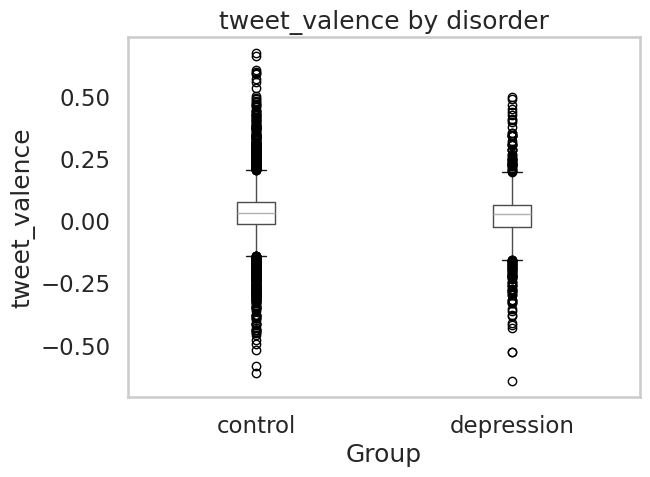

<Figure size 600x500 with 0 Axes>

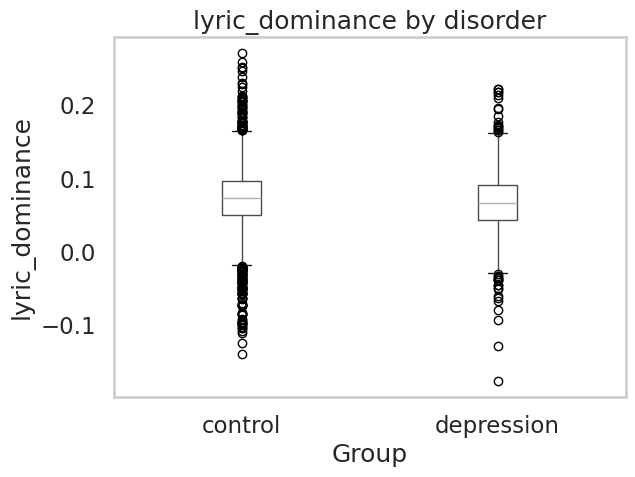

<Figure size 600x500 with 0 Axes>

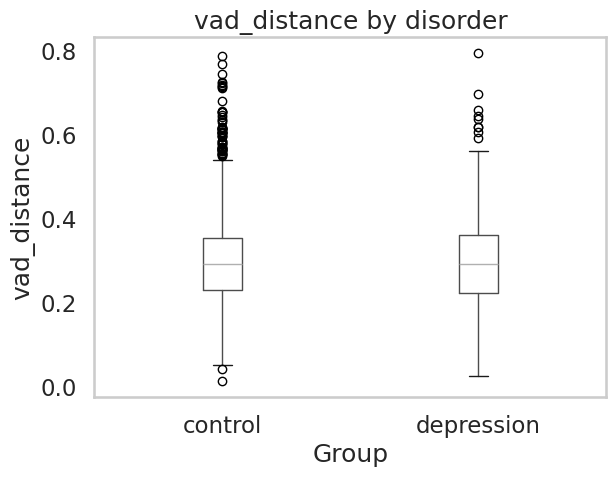

In [29]:
import matplotlib.pyplot as plt

plot_features = [
    "tweet_valence",
    "lyric_dominance",
    "vad_distance"
]

for feature in plot_features:
    plt.figure(figsize=(6, 5))

    participant_df.boxplot(
        column=feature,
        by="disorder",
        grid=False
    )

    plt.title(f"{feature} by disorder")
    plt.suptitle("")
    plt.xlabel("Group")
    plt.ylabel(feature)

    plt.show()